<div align="center">

# Binary Voice Pathology Classification

**Fine-tuning a state-of-the-art speech transformer on the SVD and FOCH Dataset**

![Python](https://img.shields.io/badge/Python-3.10+-blue?style=flat-square&logo=python)
![PyTorch](https://img.shields.io/badge/PyTorch-2.0+-EE4C2C?style=flat-square&logo=pytorch)
![HuggingFace](https://img.shields.io/badge/🤗-Transformers-FFD21F?style=flat-square)
![CUDA](https://img.shields.io/badge/CUDA-AMP%20Enabled-76B900?style=flat-square&logo=nvidia)

</div>


---

## Cell 1 — Environment & Configuration

Configures FFmpeg, defines the `MODEL_CONFIG` registry for all 9 architectures, selects the active
model with `SELECTED_MODEL`, and loads the appropriate feature extractor.

> **Before running:** verify that each `model_path` in `MODEL_CONFIG` points to a locally
> downloaded model directory. Download with `huggingface-cli download <hf_id> --local-dir <model_path>`.

In [ ]:
# CELL 1 — Imports & Environment Configuration# ═══════════════════════════════════════════════════════════════════════════
# 🎛️  MODEL SWITCHING GUIDE
# ═══════════════════════════════════════════════════════════════════════════
# TO SWITCH MODELS:
#   1. Change SELECTED_MODEL below to any key in MODEL_CONFIG
#   2. Re-run this cell  → loads correct processor
#   3. Re-run Cell 2     → data stays identical, processor-agnostic
#   4. Re-run Cell 3     → dataset rebuilt with new processor
#   5. Re-run Cell 4     → DataLoaders with new batch size
#   6. Re-run Cell 5     → model loaded with correct class
#   7. Re-run Cell 6     → training with model-specific LR
# ═══════════════════════════════════════════════════════════════════════════
import os, glob, random, warnings
import pandas as pd
import numpy as np
import torch
import torchaudio
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from transformers import (
    Wav2Vec2FeatureExtractor,
    Wav2Vec2ForSequenceClassification,
    WavLMForSequenceClassification,
    HubertForSequenceClassification,
    ASTFeatureExtractor,
    ASTForAudioClassification,
    WhisperFeatureExtractor,
    WhisperForAudioClassification,
    AutoProcessor,
    AutoModelForAudioClassification,
    get_cosine_schedule_with_warmup,
)
warnings.filterwarnings('ignore')

# ── FFmpeg ───────────────────────────────────────────────────────────────────
import shutil
_ffmpeg_bin = 'C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin'
os.environ['PATH'] += os.pathsep + _ffmpeg_bin
print(f'FFmpeg : {shutil.which("ffmpeg")}')

# ── MODEL REGISTRY ───────────────────────────────────────────────────────────
# Fields:
#   model_path      local directory (model must be pre-downloaded)
#   model_class     HuggingFace class name (string, resolved in Cell 5)
#   processor_class 'wav2vec2' | 'ast' | 'whisper' | 'auto'
#   input_type      'waveform' | 'spectrogram'
#   sampling_rate   expected input SR (MERT needs 24 kHz)
#   max_length_s    audio window in seconds (processor pads/truncates)
#   learning_rate   recommended LR for fine-tuning on small medical datasets
#   batch_size      per-GPU batch (tuned for RTX 2000 Super Blackwell, 8 GB VRAM)
#   freeze_fe       freeze the CNN / patch-embed feature extractor
MODEL_CONFIG = {

    # ── SPECTROGRAM-INPUT MODELS ─────────────────────────────────────────
    # AST: patch-based ViT pretrained on AudioSet (general audio events).
    # Input: log-mel patches [batch, seq_len, 128].  Good baseline for audio
    # events; may need adaptation for sustained voiced speech.
    'ast-finetuned-audioset': {
        'model_path':      'C:/Users/AdminIA/Documents/models/ast-finetuned-audioset-10-10-0.4593',
        'model_class':     'ASTForAudioClassification',
        'processor_class': 'ast',
        'input_type':      'spectrogram',
        'sampling_rate':   16000,
        'max_length_s':    2.0,
        'learning_rate':   1e-5,
        'batch_size':      8,
        'freeze_fe':       True,
        'hf_id':           'MIT/ast-finetuned-audioset-10-10-0.4593',
        'params':          '86 M',
    },

    # Whisper: ASR-pretrained encoder repurposed for classification.
    # Input: 80-bin log-mel spectrogram [batch, 80, 3000] (30-s window;
    # shorter audio is zero-padded automatically by the feature extractor).
    'whisper-base': {
        'model_path':      'C:/Users/AdminIA/Documents/models/whisper-base',
        'model_class':     'WhisperForAudioClassification',
        'processor_class': 'whisper',
        'input_type':      'spectrogram',
        'sampling_rate':   16000,
        'max_length_s':    2.0,
        'learning_rate':   1e-4,
        'batch_size':      16,
        'freeze_fe':       False,
        'hf_id':           'openai/whisper-base',
        'params':          '74 M',
    },

    # ── RAW-WAVEFORM MODELS ──────────────────────────────────────────────
    # wav2vec2-base: lightweight 95 M contrastive SSL baseline.
    # Fast to train; useful as a lower-bound for the benchmark.
    'wav2vec2-base': {
        'model_path':      'C:/Users/AdminIA/Documents/models/wav2vec2-base',
        'model_class':     'Wav2Vec2ForSequenceClassification',
        'processor_class': 'wav2vec2',
        'input_type':      'waveform',
        'sampling_rate':   16000,
        'max_length_s':    2.0,
        'learning_rate':   1e-4,
        'batch_size':      16,
        'freeze_fe':       True,
        'hf_id':           'facebook/wav2vec2-base',
        'params':          '95 M',
    },

    # wav2vec2-large-960h: large Wav2Vec2 fine-tuned on LibriSpeech ASR.
    # ASR fine-tuning may help transfer to voice pathology detection.
    'wav2vec2-large-960h': {
        'model_path':      'C:/Users/AdminIA/Documents/models/wav2vec2-large-960h',
        'model_class':     'Wav2Vec2ForSequenceClassification',
        'processor_class': 'wav2vec2',
        'input_type':      'waveform',
        'sampling_rate':   16000,
        'max_length_s':    2.0,
        'learning_rate':   5e-5,
        'batch_size':      4,
        'freeze_fe':       True,
        'hf_id':           'facebook/wav2vec2-large-960h',
        'params':          '317 M',
    },

    # wav2vec2-large-robust: noise-robust variant trained on diverse speech
    # (telephone, far-field, noisy).  May generalise better across recording
    # conditions from different clinical microphones.
    'wav2vec2-large-robust': {
        'model_path':      'C:/Users/AdminIA/Documents/models/wav2vec2-large-robust',
        'model_class':     'Wav2Vec2ForSequenceClassification',
        'processor_class': 'wav2vec2',
        'input_type':      'waveform',
        'sampling_rate':   16000,
        'max_length_s':    2.0,
        'learning_rate':   5e-5,
        'batch_size':      4,
        'freeze_fe':       True,
        'hf_id':           'facebook/wav2vec2-large-robust',
        'params':          '317 M',
    },

    # wavlm-base: adds denoising pre-training objective to wav2vec2.
    # Good balance of speed and quality; excellent starting point.
    'wavlm-base': {
        'model_path':      'C:/Users/AdminIA/Documents/models/wavlm-base',
        'model_class':     'WavLMForSequenceClassification',
        'processor_class': 'wav2vec2',
        'input_type':      'waveform',
        'sampling_rate':   16000,
        'max_length_s':    2.0,
        'learning_rate':   1e-4,
        'batch_size':      16,
        'freeze_fe':       True,
        'hf_id':           'microsoft/wavlm-base',
        'params':          '94 M',
    },

    # wavlm-large: SOTA speech SSL model.  Gated relative position bias +
    # denoising pre-training.  Previously used in foch_test.ipynb.
    'wavlm-large': {
        'model_path':      'C:/Users/AdminIA/Documents/models/wavlm-large',
        'model_class':     'WavLMForSequenceClassification',
        'processor_class': 'wav2vec2',
        'input_type':      'waveform',
        'sampling_rate':   16000,
        'max_length_s':    2.0,
        'learning_rate':   1e-5,
        'batch_size':      4,
        'freeze_fe':       True,
        'hf_id':           'microsoft/wavlm-large',
        'params':          '316 M',
    },

    # hubert-base: BERT-style masked prediction on raw audio.
    # Strong baseline for paralinguistic tasks.
    'hubert-base-ls960': {
        'model_path':      'C:/Users/AdminIA/Documents/models/hubert-base-ls960',
        'model_class':     'HubertForSequenceClassification',
        'processor_class': 'wav2vec2',
        'input_type':      'waveform',
        'sampling_rate':   16000,
        'max_length_s':    2.0,
        'learning_rate':   1e-4,
        'batch_size':      8,
        'freeze_fe':       True,
        'hf_id':           'facebook/hubert-base-ls960',
        'params':          '94 M',
    },

    # MERT-v1-330M: music-pretrained model with RVQ acoustic teacher.
    # NOTE: requires 24 kHz input — resampling handled automatically.
    # Uses AutoModelForAudioClassification + trust_remote_code=True.
    'MERT-v1-330M': {
        'model_path':      'C:/Users/AdminIA/Documents/models/MERT-v1-330M',
        'model_class':     'AutoModelForAudioClassification',
        'processor_class': 'auto',
        'input_type':      'waveform',
        'sampling_rate':   24000,
        'max_length_s':    2.0,
        'learning_rate':   5e-6,
        'batch_size':      4,
        'freeze_fe':       True,
        'hf_id':           'm-a-p/MERT-v1-330M',
        'params':          '330 M',
    },
}

# ── SELECT ACTIVE MODEL ──────────────────────────────────────────────────────
SELECTED_MODEL = 'wavlm-large'     # ← change this to switch architectures

cfg       = MODEL_CONFIG[SELECTED_MODEL]
TARGET_SR = cfg['sampling_rate']
MAX_LEN_S = cfg['max_length_s']

# ── PROCESSOR LOADING ────────────────────────────────────────────────────────
PROCESSOR_CLASS_MAP = {
    'wav2vec2': Wav2Vec2FeatureExtractor,
    'ast':      ASTFeatureExtractor,
    'whisper':  WhisperFeatureExtractor,
}

def load_processor(cfg):
    pc = cfg['processor_class']
    if pc == 'auto':
        return AutoProcessor.from_pretrained(cfg['model_path'], trust_remote_code=True)
    return PROCESSOR_CLASS_MAP[pc].from_pretrained(cfg['model_path'])

processor = load_processor(cfg)
print(f'\u2713 Processor loaded : {type(processor).__name__}')

# ── DATA PATHS ───────────────────────────────────────────────────────────────
FOCH_PATH        = 'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Best'
SVD_HEALTHY_PATH = 'C:/Users/AdminIA/Documents/SVD/healthy'

print(f"\n{'='*70}")
print(f'Active model   : {SELECTED_MODEL}')
print(f'HuggingFace ID : {cfg["hf_id"]}')
print(f'Parameters     : {cfg["params"]}')
print(f'Input type     : {cfg["input_type"]}')
print(f'Sampling rate  : {TARGET_SR} Hz')
print(f'Max audio      : {MAX_LEN_S} s')
print(f'Learning rate  : {cfg["learning_rate"]}')
print(f'Batch size     : {cfg["batch_size"]}')
print(f'Freeze feat.ex : {cfg["freeze_fe"]}')
print(f"{'='*70}")  

FFmpeg : C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin\ffmpeg.EXE
✓ Processor loaded : Wav2Vec2FeatureExtractor

Active model   : wavlm-large
HuggingFace ID : microsoft/wavlm-large
Parameters     : 316 M
Input type     : waveform
Sampling rate  : 16000 Hz
Max audio      : 2.0 s
Learning rate  : 1e-05
Batch size     : 4
Freeze feat.ex : True


---

## Cell 2 — Dataset Parsing & Class Balancing

Builds a unified DataFrame from two sources:

- **Pathological (FOCH):** flat directory — every `.wav` file is one patient recording.
- **Healthy (SVD):** crawls `<healthy_root>/<patient_id>/vowels/*a_h.wav`.
  Only `a_h` (habitual pitch) files are selected because their pitch profile matches
  the FOCH recordings most closely.

**Class balancing** applies random undersampling of the healthy class so both classes
contribute equally (1:1), preventing the model from defaulting to the majority class.

| Class | Available | After balancing |
|-------|-----------|----------------|
| Healthy (SVD `a_h`) | 2 576 | 281 |
| Pathological (FOCH) | 281 | 281 |

In [2]:
# CELL 2 — Data Parsing & Class Balancing
RANDOM_SEED = 42

# ── 1. Pathological — FOCH flat directory ────────────────────────────────────
foch_files = glob.glob(os.path.join(FOCH_PATH, '*.wav'))
df_patho = pd.DataFrame({
    'filepath':  foch_files,
    'filename':  [os.path.basename(f) for f in foch_files],
    'label_str': 'Pathological',
    'label':     1,
})
print(f'FOCH pathological recordings : {len(df_patho)}')

# ── 2. Healthy — SVD a_h files only ─────────────────────────────────────────
# Pattern: <healthy_root>/<patient_id>/vowels/<patient_id>-a_h.wav
# We use *a_h.wav (not *a_h* ) to avoid capturing a_hl, a_hn variants.
svd_ah_files = glob.glob(os.path.join(SVD_HEALTHY_PATH, '*', 'vowels', '*a_h.wav'))
print(f'SVD a_h healthy recordings   : {len(svd_ah_files)}')

# ── 3. Undersample healthy to match pathological count (1:1 ratio) ───────────
N_PATHO = len(df_patho)
random.seed(RANDOM_SEED)
svd_sampled = random.sample(svd_ah_files, min(N_PATHO, len(svd_ah_files)))

df_healthy = pd.DataFrame({
    'filepath':  svd_sampled,
    'filename':  [os.path.basename(f) for f in svd_sampled],
    'label_str': 'Healthy',
    'label':     0,
})

# ── 4. Merge & shuffle ───────────────────────────────────────────────────────
df = pd.concat([df_patho, df_healthy], ignore_index=True)
df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f'\nFinal dataset size : {len(df)}')
print(df['label_str'].value_counts().to_string())
print(f'\nSample entries:')
print(df[['filename', 'label_str']].head(10).to_string(index=False))

FOCH pathological recordings : 281
SVD a_h healthy recordings   : 687

Final dataset size : 562
label_str
Healthy         281
Pathological    281

Sample entries:
                                         filename    label_str
                                     1728-a_h.wav      Healthy
                                     1344-a_h.wav      Healthy
                                      951-a_h.wav      Healthy
                  20250103_VOYELLES_segmented.wav Pathological
                                     1995-a_h.wav      Healthy
 20250324_SITBON__20250324_VOYELLES_segmented.wav Pathological
20260216_FARADE_20260216_VOYELLES_2_segmented.wav Pathological
  20260223_TISSIR_20260223_VOYELLES_segmented.wav Pathological
                  20250127_VOYELLES_segmented.wav Pathological
                                       26-a_h.wav      Healthy


In [3]:
# At the end of Cell 2, add this line:
df.to_csv('C:/Users/AdminIA/Documents/models/foch-benchmark/foch_balanced_dataset.csv', index=False)
print(f"Dataset saved to disk for recovery after kernel restart")

Dataset saved to disk for recovery after kernel restart


---

## Cell 3 — Custom PyTorch Dataset

`FOCHDataset` is a processor-agnostic wrapper. Each `__getitem__` call:

1. Loads the `.wav` with `torchaudio`
2. Converts stereo → mono if needed
3. Resamples to the model's expected sampling rate
4. Routes through the correct processor branch:
   - **`wav2vec2` / `auto`** → raw waveform → `input_values` (1-D float tensor)
   - **`ast`** → log-mel patches → `input_values` (2-D tensor)
   - **`whisper`** → 80-bin log-mel → `input_features` [80, 3000] (zero-padded to 30 s)

Corrupted files return a zero-tensor fallback so the DataLoader never crashes mid-epoch.

In [4]:
# CELL 3 — Custom PyTorch Dataset (processor-agnostic)
class FOCHDataset(Dataset):
    def __init__(self, dataframe, processor, cfg):
        self.df           = dataframe.reset_index(drop=True)
        self.processor    = processor
        self.sr           = cfg['sampling_rate']
        self.max_len      = int(self.sr * cfg['max_length_s'])
        self.pclass       = cfg['processor_class']  # 'wav2vec2'|'ast'|'whisper'|'auto'

    def __len__(self):
        return len(self.df)

    def _process(self, wave_np):
        """Route audio through the correct feature extractor branch."""
        if self.pclass in ('wav2vec2', 'auto'):
            out = self.processor(
                wave_np,
                sampling_rate=self.sr,
                max_length=self.max_len,
                truncation=True,
                padding='max_length',
                return_tensors='pt',
            )
            return out.input_values.squeeze(0)

        elif self.pclass == 'ast':
            # ASTFeatureExtractor handles mel conversion internally;
            # returns input_values of shape [1, seq_len, num_mel_bins]
            out = self.processor(
                wave_np,
                sampling_rate=self.sr,
                return_tensors='pt',
            )
            return out.input_values.squeeze(0)

        else:  # whisper
            # WhisperFeatureExtractor always pads audio to 30-s window,
            # producing [1, 80, 3000].  WhisperForAudioClassification
            # expects this fixed shape.
            out = self.processor(
                wave_np,
                sampling_rate=self.sr,
                return_tensors='pt',
            )
            return out.input_features.squeeze(0)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row['label'])
        try:
            waveform, orig_sr = torchaudio.load(row['filepath'])
            if waveform.shape[0] > 1:
                waveform = waveform.mean(dim=0, keepdim=True)
            if orig_sr != self.sr:
                waveform = torchaudio.transforms.Resample(orig_sr, self.sr)(waveform)
            wave_np = waveform.squeeze().numpy()
            tensor  = self._process(wave_np)
        except Exception as e:
            print(f'[WARN] {row["filepath"]}: {e}')
            # Zero-tensor fallback — prevents DataLoader crash on corrupted files
            tensor = torch.zeros(self.max_len)
        return tensor, torch.tensor(label, dtype=torch.long)

---

## Cell 4 — Train / Validation Split & DataLoaders

Splits the balanced dataset **80 / 20** (stratified by label) and wraps both splits in
PyTorch `DataLoader`s.

**Configuration notes:**
- Batch size is read from `MODEL_CONFIG` — large models (316–330 M) use 4, small ones up to 16
- `num_workers = 0` — **required on Windows** to avoid multiprocessing deadlocks in Jupyter
- `pin_memory = True` — overlaps CPU→GPU transfer with GPU compute

In [5]:
# RECOVERY — Run this after kernel restart to reload data without re-parsing
import pandas as pd
df = pd.read_csv('C:/Users/AdminIA/Documents/models/foch-benchmark/foch_balanced_dataset.csv')
print(f"Dataset recovered: {len(df)} samples")
print(df['label_str'].value_counts())

# Re-initialize processor from Cell 1's cfg
processor = load_processor(cfg)

Dataset recovered: 562 samples
label_str
Healthy         281
Pathological    281
Name: count, dtype: int64


In [6]:
# CELL 4 — Train / Validation Split & DataLoaders
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=RANDOM_SEED,
)

print(f'Train : {len(train_df)} samples')
print(f'Val   : {len(val_df)} samples')
print(f'Train distribution:\n{train_df["label_str"].value_counts().to_string()}')
print(f'Val   distribution:\n{val_df["label_str"].value_counts().to_string()}')

train_ds = FOCHDataset(train_df, processor, cfg)
val_ds   = FOCHDataset(val_df,   processor, cfg)

BATCH_SIZE = cfg['batch_size']

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True,
)

print(f'\nBatch size : {BATCH_SIZE} (from {SELECTED_MODEL} config)')
print('Testing first batch...')
for xb, yb in train_loader:
    print(f'  Input shape : {xb.shape}')
    print(f'  Labels      : {yb}')
    break

Train : 449 samples
Val   : 113 samples
Train distribution:
label_str
Pathological    225
Healthy         224
Val   distribution:
label_str
Healthy         57
Pathological    56

Batch size : 4 (from wavlm-large config)
Testing first batch...
  Input shape : torch.Size([4, 32000])
  Labels      : tensor([1, 0, 1, 0])


---

## Cell 5 — Model Initialization

Loads the correct classification head variant from the local model directory and replaces
the pre-trained classification head with a new randomly-initialised one for binary output
(`num_labels = 2`). The warning about uninitialised weights is **expected** — those are the
new layers that will be trained.

**Feature extractor freezing** keeps the CNN / patch-embedding front-end frozen.
These layers act as a fixed acoustic filter bank and do not benefit from fine-tuning
on a dataset this size — keeping them frozen saves VRAM and reduces overfitting.

| Model family | Frozen component |
|--------------|------------------|
| WavLM | `model.wavlm.feature_extractor` |
| Wav2Vec2 | `model.wav2vec2.feature_extractor` |
| HuBERT | `model.hubert.feature_extractor` |
| AST | `model.audio_spectrogram_transformer.embeddings` |
| Whisper | `model.model.encoder.conv1 + conv2` |
| MERT (Auto) | first child feature extractor via `model.children()` |

In [7]:
# CELL 5 — Model Initialization
MODEL_CLASS_MAP = {
    'Wav2Vec2ForSequenceClassification': Wav2Vec2ForSequenceClassification,
    'WavLMForSequenceClassification':    WavLMForSequenceClassification,
    'HubertForSequenceClassification':   HubertForSequenceClassification,
    'ASTForAudioClassification':         ASTForAudioClassification,
    'WhisperForAudioClassification':     WhisperForAudioClassification,
    'AutoModelForAudioClassification':   AutoModelForAudioClassification,
}

NUM_LABELS = 2  # 0 = Healthy, 1 = Pathological

def load_model(cfg, num_labels):
    cls_name = cfg['model_class']
    path     = cfg['model_path']
    if cls_name == 'AutoModelForAudioClassification':
        return AutoModelForAudioClassification.from_pretrained(
            path, num_labels=num_labels,
            trust_remote_code=True, ignore_mismatched_sizes=True,
        )
    return MODEL_CLASS_MAP[cls_name].from_pretrained(
        path, num_labels=num_labels, ignore_mismatched_sizes=True,
    )

def freeze_feature_extractor(model, cfg):
    """Freeze the CNN / patch-embed feature extractor of each architecture."""
    name = cfg['model_class']
    try:
        if name == 'WavLMForSequenceClassification':
            target = model.wavlm.feature_extractor
        elif name == 'Wav2Vec2ForSequenceClassification':
            target = model.wav2vec2.feature_extractor
        elif name == 'HubertForSequenceClassification':
            target = model.hubert.feature_extractor
        elif name == 'ASTForAudioClassification':
            target = model.audio_spectrogram_transformer.embeddings
        elif name == 'WhisperForAudioClassification':
            for p in model.model.encoder.conv1.parameters():
                p.requires_grad = False
            for p in model.model.encoder.conv2.parameters():
                p.requires_grad = False
            print('\u2713 Froze WhisperEncoder conv1 + conv2')
            return
        else:
            # MERT / AutoModel: freeze the first child module (feature extractor)
            target = next(model.children())
        for p in target.parameters():
            p.requires_grad = False
        print(f'\u2713 Froze {name} feature extractor')
    except (AttributeError, StopIteration) as e:
        print(f'\u26a0  Could not freeze feature extractor ({e}) — continuing without freeze')

model = load_model(cfg, NUM_LABELS)
print(f'\u2713 Model loaded : {cfg["model_class"]}')

if cfg['freeze_fe']:
    freeze_feature_extractor(model, cfg)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nDevice           : {device}')
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}  ({100*trainable/total:.1f} %)')
print(f'Output classes   : {NUM_LABELS}  (0=Healthy, 1=Pathological)')

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

[transformers] WavLMForSequenceClassification LOAD REPORT from: C:/Users/AdminIA/Documents/models/wavlm-large
Key               | Status  | 
------------------+---------+-
projector.bias    | MISSING | 
projector.weight  | MISSING | 
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Model loaded : WavLMForSequenceClassification
✓ Froze WavLMForSequenceClassification feature extractor

Device           : cuda
Total params     : 315,716,034
Trainable params : 311,509,442  (98.7 %)
Output classes   : 2  (0=Healthy, 1=Pathological)


---

## Cell 6 — Optimized Training Loop

Identical strategy to `foch_test.ipynb`, adapted for the smaller FOCH dataset.

| Technique | Benefit |
|-----------|---------|
| **AMP** (`autocast` + `GradScaler`) | ~50 % less VRAM, 2–3× faster on CUDA |
| **Gradient accumulation** (×4 steps) | Effective batch of `batch_size × 4` without extra VRAM |
| **`non_blocking=True` transfers** | Overlaps host→device copy with GPU compute |
| **Cosine LR + 10 % warmup** | Smoother convergence, avoids flat-LR plateau |
| **AdamW `weight_decay=0.01`** | Regularises transformer on small dataset |
| **Early stopping** (patience = 5) | Halts automatically when val loss plateaus |
| **Best checkpoint + periodic saves** | `best_model.pt` on every improvement |

Checkpoints are saved to `C:/Users/AdminIA/Documents/models/foch-benchmark/<model_name>/`.

In [8]:
# CELL 6 — Training Loop
from torch.amp import GradScaler, autocast

EPOCHS             = 30
ACCUMULATION_STEPS = 4
PATIENCE           = 5

CKPT_DIR = os.path.join(
    'C:/Users/AdminIA/Documents/models/foch-benchmark',
    SELECTED_MODEL.replace('/', '_'),
)
os.makedirs(CKPT_DIR, exist_ok=True)

LR = cfg['learning_rate']
print(f'LR : {LR}  |  Eff. batch : {BATCH_SIZE * ACCUMULATION_STEPS}  |  Checkpoints → {CKPT_DIR}\n')

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=0.01,
)
criterion    = nn.CrossEntropyLoss()
total_steps  = (len(train_loader) // ACCUMULATION_STEPS) * EPOCHS
warmup_steps = total_steps // 10
scheduler    = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)
scaler = GradScaler()

train_loss_hist, val_loss_hist = [], []
best_val_loss = float('inf')
patience_ctr  = 0

print(f'Training up to {EPOCHS} epochs  |  early-stop patience={PATIENCE}')

for epoch in range(EPOCHS):

    # ── TRAIN ────────────────────────────────────────────────────────────
    model.train()
    ep_tr, corr_tr, tot_tr = 0.0, 0, 0
    optimizer.zero_grad()

    for i, (xb, yb) in enumerate(train_loader):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        with autocast(device_type='cuda'):
            logits = model(xb).logits
            loss   = criterion(logits, yb) / ACCUMULATION_STEPS

        scaler.scale(loss).backward()
        ep_tr  += loss.item() * ACCUMULATION_STEPS
        preds   = logits.detach().argmax(dim=1)
        corr_tr += (preds == yb).sum().item()
        tot_tr  += yb.size(0)

        if (i + 1) % ACCUMULATION_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        if (i + 1) % 20 == 0:
            print(f'  Ep {epoch+1} | Batch {i+1}/{len(train_loader)} | LR {scheduler.get_last_lr()[0]:.2e}')

    avg_tr = ep_tr / len(train_loader)
    train_loss_hist.append(avg_tr)

    # ── VALIDATE ─────────────────────────────────────────────────────────
    model.eval()
    ep_v, corr_v, tot_v = 0.0, 0, 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            with autocast(device_type='cuda'):
                logits = model(xb).logits
                loss   = criterion(logits, yb)
            ep_v  += loss.item()
            corr_v += (logits.argmax(1) == yb).sum().item()
            tot_v  += yb.size(0)

    avg_v = ep_v / len(val_loader)
    val_loss_hist.append(avg_v)

    print(f'Epoch {epoch+1:02d}/{EPOCHS} | '
          f'Train {avg_tr:.4f}/{corr_tr/tot_tr:.3f} | '
          f'Val   {avg_v:.4f}/{corr_v/tot_v:.3f}')

    # ── CHECKPOINT & EARLY STOPPING ──────────────────────────────────────
    if avg_v < best_val_loss:
        best_val_loss = avg_v
        torch.save(model.state_dict(), os.path.join(CKPT_DIR, 'best_model.pt'))
        print(f'  \u2192 Best saved  (Val Loss {best_val_loss:.4f})')
        patience_ctr = 0
    else:
        patience_ctr += 1
        print(f'  \u2192 No improve  ({patience_ctr}/{PATIENCE})')
        if patience_ctr >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}.')
            break

    if (epoch + 1) % 5 == 0:
        torch.save({
            'epoch':            epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer':        optimizer.state_dict(),
            'scaler':           scaler.state_dict(),
            'train_loss_hist':  train_loss_hist,
            'val_loss_hist':    val_loss_hist,
        }, os.path.join(CKPT_DIR, f'ckpt_epoch{epoch+1}.pt'))
        print(f'  \u2192 Periodic checkpoint saved (epoch {epoch+1})')

print('\nTraining complete.')

LR : 1e-05  |  Eff. batch : 16  |  Checkpoints → C:/Users/AdminIA/Documents/models/foch-benchmark\wavlm-large

Training up to 30 epochs  |  early-stop patience=5
  Ep 1 | Batch 20/113 | LR 5.95e-07
  Ep 1 | Batch 40/113 | LR 1.19e-06
  Ep 1 | Batch 60/113 | LR 1.79e-06
  Ep 1 | Batch 80/113 | LR 2.38e-06
  Ep 1 | Batch 100/113 | LR 2.98e-06
Epoch 01/30 | Train 0.6922/0.552 | Val   0.6881/0.664
  → Best saved  (Val Loss 0.6881)
  Ep 2 | Batch 20/113 | LR 3.93e-06
  Ep 2 | Batch 40/113 | LR 4.52e-06
  Ep 2 | Batch 60/113 | LR 5.12e-06
  Ep 2 | Batch 80/113 | LR 5.71e-06
  Ep 2 | Batch 100/113 | LR 6.31e-06
Epoch 02/30 | Train 0.6863/0.650 | Val   0.6729/0.708
  → Best saved  (Val Loss 0.6729)
  Ep 3 | Batch 20/113 | LR 7.26e-06
  Ep 3 | Batch 40/113 | LR 7.86e-06
  Ep 3 | Batch 60/113 | LR 8.45e-06
  Ep 3 | Batch 80/113 | LR 9.05e-06
  Ep 3 | Batch 100/113 | LR 9.64e-06
Epoch 03/30 | Train 0.6674/0.684 | Val   0.6353/0.726
  → Best saved  (Val Loss 0.6353)
  Ep 4 | Batch 20/113 | LR 1.00

---

## Cell 7 — Clinical Evaluation & Visualizations

Runs full inference on the validation set and renders a 2×2 diagnostic dashboard.

| Panel | Description |
|-------|-------------|
| **Confusion Matrix** | Absolute prediction counts per true class |
| **ROC Curve + AUC** | Sensitivity vs. specificity trade-off across decision thresholds |
| **Precision-Recall Curve** | Performance under the class imbalance scenario |
| **Learning Curves** | Training vs. validation loss across epochs |

The **positive class is Pathological (1)**. ROC AUC is the primary headline metric for
clinical screening tasks (maximise sensitivity without flooding with false positives).

The dashboard is also saved as a PNG alongside the model checkpoint.

Running inference on validation set...

────────────────────────────────────────────────────────────
Model : wavlm-large
────────────────────────────────────────────────────────────
                  precision    recall  f1-score   support

     Healthy (0)       0.98      1.00      0.99        57
Pathological (1)       1.00      0.98      0.99        56

        accuracy                           0.99       113
       macro avg       0.99      0.99      0.99       113
    weighted avg       0.99      0.99      0.99       113



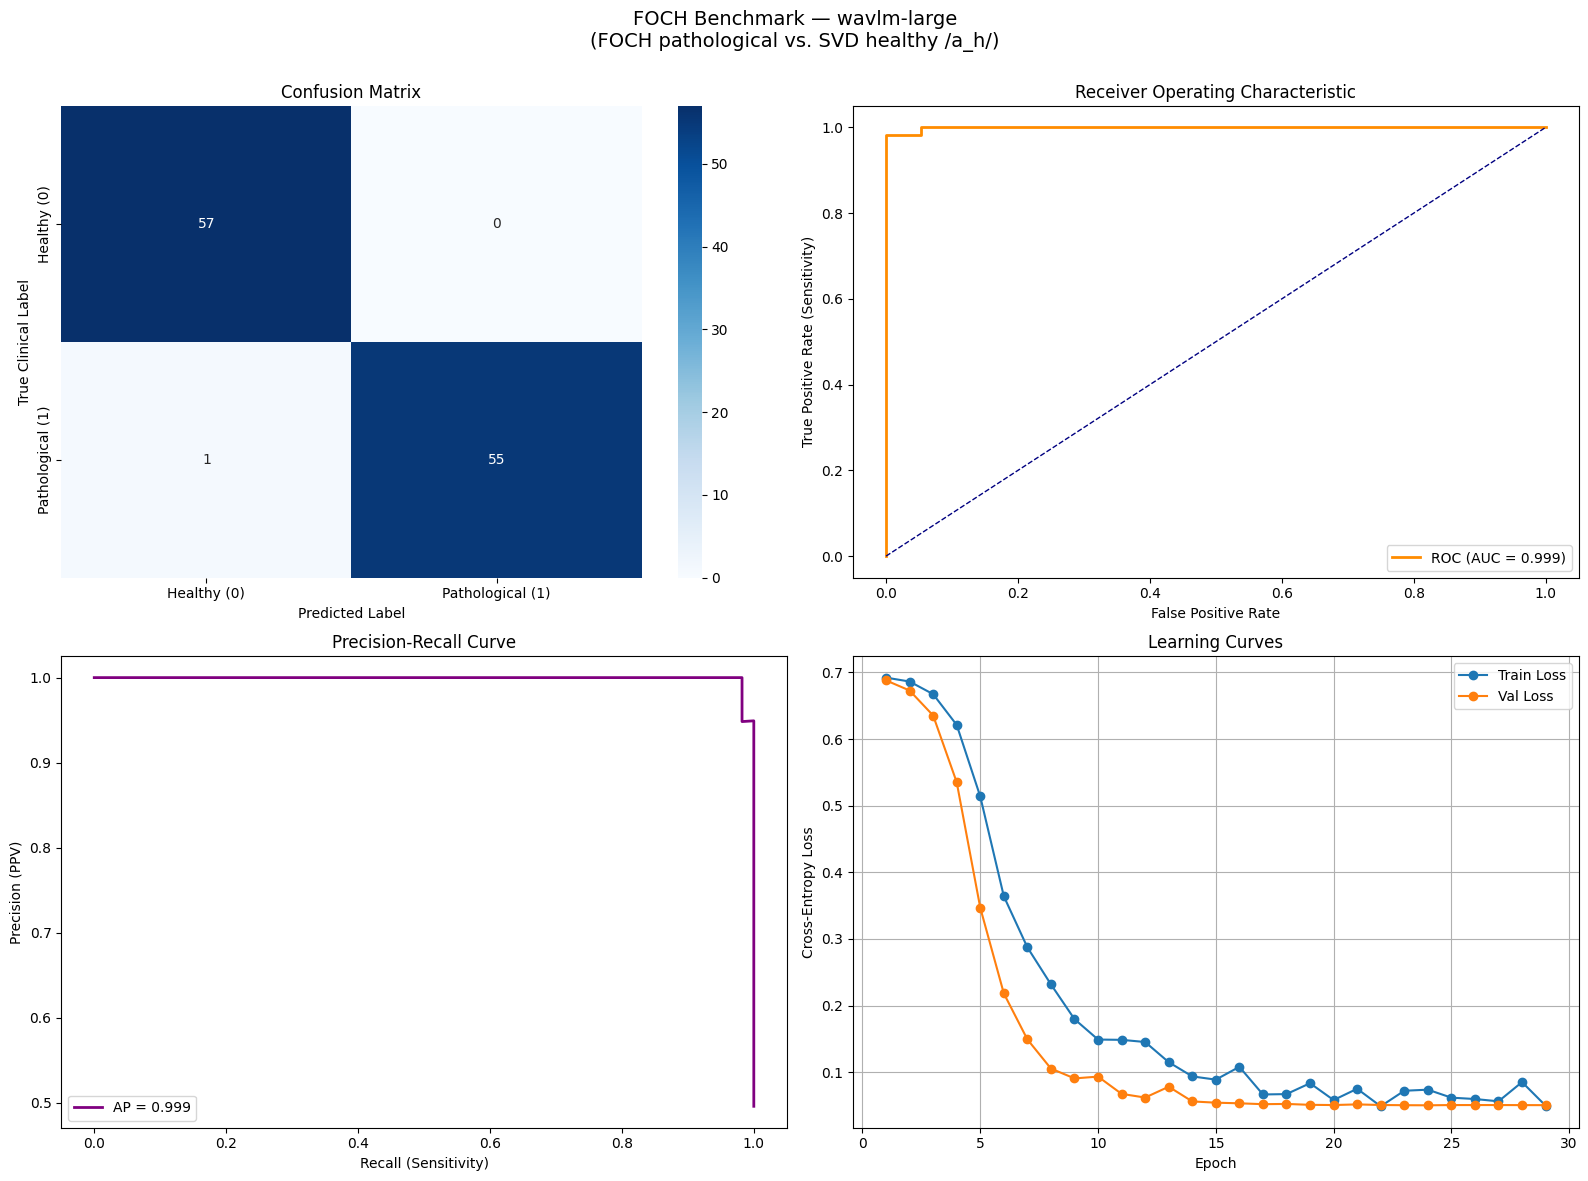


Key metrics — wavlm-large
  ROC AUC        : 0.9991
  Avg. Precision : 0.9991
  Dashboard saved to C:/Users/AdminIA/Documents/models/foch-benchmark\wavlm-large/eval_dashboard.png


In [9]:
# CELL 7 — Clinical Evaluation & Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score,
)

model.eval()
all_labels, all_preds, all_probs = [], [], []

print('Running inference on validation set...')
with torch.no_grad():
    for xb, yb in val_loader:
        xb     = xb.to(device)
        logits = model(xb).logits
        probs  = F.softmax(logits, dim=1)
        preds  = logits.argmax(dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.numpy())

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)
target_names = ['Healthy (0)', 'Pathological (1)']

print('\n' + '─' * 60)
print(f'Model : {SELECTED_MODEL}')
print('─' * 60)
print(classification_report(all_labels, all_preds, target_names=target_names))

# ── 2×2 Dashboard ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    f'FOCH Benchmark — {SELECTED_MODEL}\n'
    f'(FOCH pathological vs. SVD healthy /a_h/)',
    fontsize=14,
)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=target_names, yticklabels=target_names)
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_ylabel('True Clinical Label')
axes[0, 0].set_xlabel('Predicted Label')

# ROC Curve
pos_probs = all_probs[:, 1]
fpr, tpr, _ = roc_curve(all_labels, pos_probs)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, lw=2, color='darkorange', label=f'ROC (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], '--', color='navy', lw=1)
axes[0, 1].set_title('Receiver Operating Characteristic')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate (Sensitivity)')
axes[0, 1].legend(loc='lower right')

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(all_labels, pos_probs)
ap = average_precision_score(all_labels, pos_probs)
axes[1, 0].plot(rec, prec, lw=2, color='purple', label=f'AP = {ap:.3f}')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].set_xlabel('Recall (Sensitivity)')
axes[1, 0].set_ylabel('Precision (PPV)')
axes[1, 0].legend()

# Learning Curves
try:
    ep_range = range(1, len(train_loss_hist) + 1)
    axes[1, 1].plot(ep_range, train_loss_hist, 'o-', label='Train Loss')
    axes[1, 1].plot(ep_range, val_loss_hist,   'o-', label='Val Loss')
    axes[1, 1].set_title('Learning Curves')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Cross-Entropy Loss')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
except NameError:
    axes[1, 1].text(0.5, 0.5, 'Run Cell 6 to populate learning curves.',
                    ha='center', va='center')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.savefig(os.path.join(CKPT_DIR, 'eval_dashboard.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nKey metrics — {SELECTED_MODEL}')
print(f'  ROC AUC        : {roc_auc:.4f}')
print(f'  Avg. Precision : {ap:.4f}')
print(f'  Dashboard saved to {CKPT_DIR}/eval_dashboard.png')

---
## Cell to optimize the VRAM of the GPU

After running this cell it will liberate the VRAM of the GPU of the computer thanks to the `.empty_cache()` function in pytorch and to see the VRAM that is left in the GPU you can use `.memory_allocated()` 

In [10]:
# CLEANUP CELL — Run after Cell 7 to free VRAM between model runs
# NOTE: train_loader / val_loader are CPU-only objects (no VRAM) — kept
# so Cell 9 fine-tuning can run without rebuilding the DataLoaders.
print("Clearing VRAM...")
del model
del optimizer, scheduler, scaler, criterion
import gc
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM cleared. GPU memory: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

Clearing VRAM...
VRAM cleared. GPU memory: 0.07 GB


---

## Cell 8 — Benchmark Results Table

After running Cells 1–7 for each of the 9 architectures, paste the `roc_auc` and `ap`
scores printed by Cell 7 into `BENCHMARK_RESULTS` below.

The table is then sorted by `Val AUC` to identify the best model for fine-tuning (Cell 9).

> **Workflow:** switch `SELECTED_MODEL` → run Cells 1 → 4 → 5 → 6 → 7 → paste metrics here.

In [ ]:
# CELL 8 — Benchmark Results Table
# ─────────────────────────────────────────────────────────────────────────────
# Fill in (val_auc, avg_precision, val_acc) as you complete each run.
# Leave None for models not yet evaluated.
# ─────────────────────────────────────────────────────────────────────────────
BENCHMARK_RESULTS = {
    # model_name: (val_auc, avg_precision, val_acc)
    'ast-finetuned-audioset':  (0.9878, 0.9927, 0.98), # Runtime of 4 min
    'hubert-base-ls960':       (0.9715, 0.9496, 0.96), # Runtime of 3 min
    'MERT-v1-330M':            (0.9969, 0.9967, 0.97), # Runtime of 9 min
    'wav2vec2-base':           (0.9925, 0.9911, 0.95), # Runtime of 5 min
    'wav2vec2-large-960h':     (0.4546, 0.4716, 0.49), # Runtime of 20 min 
    'wav2vec2-large-robust':   (0.9975, 0.9975, 0.96), # Runtime of 8 min
    'wavlm-base':              (0.9953, 0.9953, 0.95), # Runtime of 3 min
    'wavlm-large':             (0.9991, 0.9991, 0.99), # Runtime of 13 min
    'whisper-base':            (0.9952, 0.9947, 0.97), # Runtime of 4 min
}

rows = []
for mname, (a, ap_v, acc) in BENCHMARK_RESULTS.items():
    mcfg = MODEL_CONFIG[mname]
    rows.append({
        'Model':        mname,
        'Params':       mcfg['params'],
        'Input':        mcfg['input_type'],
        'Val AUC':      f'{a:.3f}'  if a    is not None else '—',
        'Avg Prec':     f'{ap_v:.3f}' if ap_v is not None else '—',
        'Val Acc':      f'{acc:.3f}' if acc  is not None else '—',
    })

df_bench = pd.DataFrame(rows)
filled  = df_bench[df_bench['Val AUC'] != '—'].sort_values('Val AUC', ascending=False)
pending = df_bench[df_bench['Val AUC'] == '—']
df_bench = pd.concat([filled, pending]).reset_index(drop=True)

sep = '=' * 80
print(sep)
print('FOCH Voice Pathology Benchmark — Binary (Healthy vs. Pathological)')
print(f'Data: {len(df_patho)} FOCH pathological  +  {len(df_healthy)} SVD a_h healthy')
print(sep)
print(df_bench.to_string(index=False))
print(sep)
if filled.empty:
    print('\n\u2192 No results yet — run Cells 1–7 for each model and paste metrics above.')
else:
    best = filled.iloc[0]['Model']
    print(f'\n\u2192 Best model so far: {best}  (proceed to Cell 9 for fine-tuning)')

FOCH Voice Pathology Benchmark — Binary (Healthy vs. Pathological)
Data: 281 FOCH pathological  +  281 SVD a_h healthy
                 Model Params       Input Val AUC Avg Prec Val Acc
           wavlm-large  316 M    waveform   0.999    0.999   0.960
 wav2vec2-large-robust  317 M    waveform   0.998    0.998   0.960
          MERT-v1-330M  330 M    waveform   0.997    0.997   0.970
            wavlm-base   94 M    waveform   0.995    0.995   0.950
          whisper-base   74 M spectrogram   0.995    0.995   0.970
         wav2vec2-base   95 M    waveform   0.993    0.991   0.950
ast-finetuned-audioset   86 M spectrogram   0.988    0.993   0.980
     hubert-base-ls960   94 M    waveform   0.972    0.950   0.960
   wav2vec2-large-960h  317 M    waveform   0.455    0.472   0.490

→ Best model so far: wavlm-large  (proceed to Cell 9 for fine-tuning)


---

## Cell 9 — Fine-Tuning the Best Model

Run this cell **after** completing the benchmark.  Set `BEST_MODEL` to whichever
architecture achieved the highest Val AUC in Cell 8.

**Fine-tuning strategy vs. benchmark run:**

| Setting | Benchmark | Fine-tuning |
|---------|-----------|-------------|
| Checkpoint | random init | `best_model.pt` from Cell 6 |
| Learning rate | model default | 10× lower |
| Frozen layers | CNN front-end only | CNN + bottom transformer layers |
| Trainable layers | all transformer layers | top 6 only (progressive unfreezing) |
| Max epochs | 30 | 50 |
| Early-stop patience | 5 | 10 |

Progressive unfreezing prevents the bottom layers (which encode general acoustic
features) from being overwritten on a dataset of only 562 samples.

In [12]:
# CELL 9 — Fine-Tuning the Best Model
# ─────────────────────────────────────────────────────────────────────────────
# Set BEST_MODEL to the top entry from Cell 8, then run this cell.
# ─────────────────────────────────────────────────────────────────────────────
BEST_MODEL  = 'wavlm-large'   # ← set to your best model from Cell 8
ft_cfg      = MODEL_CONFIG[BEST_MODEL]
FINETUNE_LR = ft_cfg['learning_rate'] * 0.1

# ── Load best checkpoint ─────────────────────────────────────────────────────
BEST_CKPT_DIR = os.path.join(
    'C:/Users/AdminIA/Documents/models/foch-benchmark',
    BEST_MODEL.replace('/', '_'),
)
best_ckpt_path = os.path.join(BEST_CKPT_DIR, 'best_model.pt')

ft_model = load_model(ft_cfg, NUM_LABELS)
ft_model.load_state_dict(torch.load(best_ckpt_path, map_location='cpu'))
print(f'\u2713 Checkpoint loaded : {best_ckpt_path}')

# ── Progressive unfreezing — keep bottom layers frozen, unfreeze top 6 ────────
def unfreeze_top_layers(model, model_class_name, n_layers=6):
    """Unfreeze the top-n transformer encoder layers for fine-tuning."""
    layer_map = {
        'WavLMForSequenceClassification':    lambda m: m.wavlm.encoder.layers,
        'Wav2Vec2ForSequenceClassification': lambda m: m.wav2vec2.encoder.layers,
        'HubertForSequenceClassification':   lambda m: m.hubert.encoder.layers,
        'ASTForAudioClassification':         lambda m: m.audio_spectrogram_transformer.encoder.layer,
        'WhisperForAudioClassification':     lambda m: m.model.encoder.layers,
    }
    try:
        layers = layer_map[model_class_name](model)
    except KeyError:
        # AutoModel (MERT): generic fallback
        all_params = list(model.parameters())
        for p in all_params[-n_layers * 10:]:
            p.requires_grad = True
        print(f'\u2713 Unfroze last {n_layers * 10} parameter tensors (AutoModel fallback)')
        return
    for layer in list(layers)[-n_layers:]:
        for p in layer.parameters():
            p.requires_grad = True
    tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
    tot = sum(p.numel() for p in model.parameters())
    print(f'\u2713 Unfroze top {n_layers} transformer layers | Trainable: {tr:,} / {tot:,}')

# First freeze everything (carry over the benchmark frozen state)
for p in ft_model.parameters():
    p.requires_grad = False
# Then unfreeze: classification head + top 6 transformer layers
for p in ft_model.parameters():
    if p.shape[0] in (NUM_LABELS, 256):   # classifier + projector
        p.requires_grad = True
unfreeze_top_layers(ft_model, ft_cfg['model_class'], n_layers=6)

ft_model.to(device)

# ── Fine-tuning loop (identical structure to Cell 6) ──────────────────────────
FT_EPOCHS       = 50
FT_ACCUMULATION = 4
FT_PATIENCE     = 10
FT_CKPT_DIR     = os.path.join(BEST_CKPT_DIR, 'finetuned')
os.makedirs(FT_CKPT_DIR, exist_ok=True)

ft_optimizer    = optim.AdamW(
    filter(lambda p: p.requires_grad, ft_model.parameters()),
    lr=FINETUNE_LR, weight_decay=0.01,
)
ft_total_steps  = (len(train_loader) // FT_ACCUMULATION) * FT_EPOCHS
ft_warmup       = ft_total_steps // 10
ft_scheduler    = get_cosine_schedule_with_warmup(
    ft_optimizer, num_warmup_steps=ft_warmup, num_training_steps=ft_total_steps,
)
ft_scaler       = GradScaler()
ft_criterion    = nn.CrossEntropyLoss()

ft_train_hist, ft_val_hist = [], []
ft_best_val = float('inf')
ft_patience = 0

print(f'\nFine-tuning {BEST_MODEL}  |  LR={FINETUNE_LR:.1e}  |  Epochs={FT_EPOCHS}  |  Patience={FT_PATIENCE}')

for epoch in range(FT_EPOCHS):
    ft_model.train()
    ep_tr, corr_tr, tot_tr = 0.0, 0, 0
    ft_optimizer.zero_grad()

    for i, (xb, yb) in enumerate(train_loader):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        with autocast(device_type='cuda'):
            logits = ft_model(xb).logits
            loss   = ft_criterion(logits, yb) / FT_ACCUMULATION
        ft_scaler.scale(loss).backward()
        ep_tr  += loss.item() * FT_ACCUMULATION
        corr_tr += (logits.detach().argmax(1) == yb).sum().item()
        tot_tr  += yb.size(0)
        if (i + 1) % FT_ACCUMULATION == 0:
            ft_scaler.unscale_(ft_optimizer)
            torch.nn.utils.clip_grad_norm_(ft_model.parameters(), 1.0)
            ft_scaler.step(ft_optimizer)
            ft_scaler.update()
            ft_scheduler.step()
            ft_optimizer.zero_grad()

    ft_train_hist.append(ep_tr / len(train_loader))

    ft_model.eval()
    ep_v, corr_v, tot_v = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            with autocast(device_type='cuda'):
                logits = ft_model(xb).logits
                loss   = ft_criterion(logits, yb)
            ep_v  += loss.item()
            corr_v += (logits.argmax(1) == yb).sum().item()
            tot_v  += yb.size(0)

    avg_v = ep_v / len(val_loader)
    ft_val_hist.append(avg_v)

    print(f'FT Epoch {epoch+1:02d}/{FT_EPOCHS} | '
          f'Train {ft_train_hist[-1]:.4f}/{corr_tr/tot_tr:.3f} | '
          f'Val   {avg_v:.4f}/{corr_v/tot_v:.3f}')

    if avg_v < ft_best_val:
        ft_best_val = avg_v
        torch.save(ft_model.state_dict(), os.path.join(FT_CKPT_DIR, 'best_finetuned.pt'))
        print(f'  \u2192 Best fine-tuned saved (Val Loss {ft_best_val:.4f})')
        ft_patience = 0
    else:
        ft_patience += 1
        if ft_patience >= FT_PATIENCE:
            print(f'Fine-tuning early stop at epoch {epoch+1}.')
            break

print(f'\nFine-tuning complete.')
print(f'Best model saved to : {os.path.join(FT_CKPT_DIR, "best_finetuned.pt")}')

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

[transformers] WavLMForSequenceClassification LOAD REPORT from: C:/Users/AdminIA/Documents/models/wavlm-large
Key               | Status  | 
------------------+---------+-
projector.bias    | MISSING | 
projector.weight  | MISSING | 
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Checkpoint loaded : C:/Users/AdminIA/Documents/models/foch-benchmark\wavlm-large\best_model.pt
✓ Unfroze top 6 transformer layers | Trainable: 75,843,474 / 315,716,034

Fine-tuning wavlm-large  |  LR=1.0e-06  |  Epochs=50  |  Patience=10
FT Epoch 01/50 | Train 0.0544/0.987 | Val   0.0504/0.991
  → Best fine-tuned saved (Val Loss 0.0504)
FT Epoch 02/50 | Train 0.0770/0.984 | Val   0.0504/0.991
FT Epoch 03/50 | Train 0.0642/0.987 | Val   0.0504/0.991
  → Best fine-tuned saved (Val Loss 0.0504)
FT Epoch 04/50 | Train 0.0700/0.984 | Val   0.0504/0.991
  → Best fine-tuned saved (Val Loss 0.0504)
FT Epoch 05/50 | Train 0.0423/0.996 | Val   0.0503/0.991
  → Best fine-tuned saved (Val Loss 0.0503)
FT Epoch 06/50 | Train 0.0426/0.991 | Val   0.0502/0.991
  → Best fine-tuned saved (Val Loss 0.0502)
FT Epoch 07/50 | Train 0.0476/0.989 | Val   0.0501/0.991
  → Best fine-tuned saved (Val Loss 0.0501)
FT Epoch 08/50 | Train 0.0588/0.987 | Val   0.0501/0.991
  → Best fine-tuned saved (Val Loss 0.05

---

## Cell 10 — Fine-Tuned Model Evaluation

Same 2×2 diagnostic dashboard as Cell 7, but evaluated on `ft_model` (the fine-tuned checkpoint).
Compare the metrics directly against Cell 8 to quantify the gain from fine-tuning.

Running inference on validation set (fine-tuned model)...

────────────────────────────────────────────────────────────
Fine-tuned model : wavlm-large
────────────────────────────────────────────────────────────
                  precision    recall  f1-score   support

     Healthy (0)       0.98      1.00      0.99        57
Pathological (1)       1.00      0.98      0.99        56

        accuracy                           0.99       113
       macro avg       0.99      0.99      0.99       113
    weighted avg       0.99      0.99      0.99       113



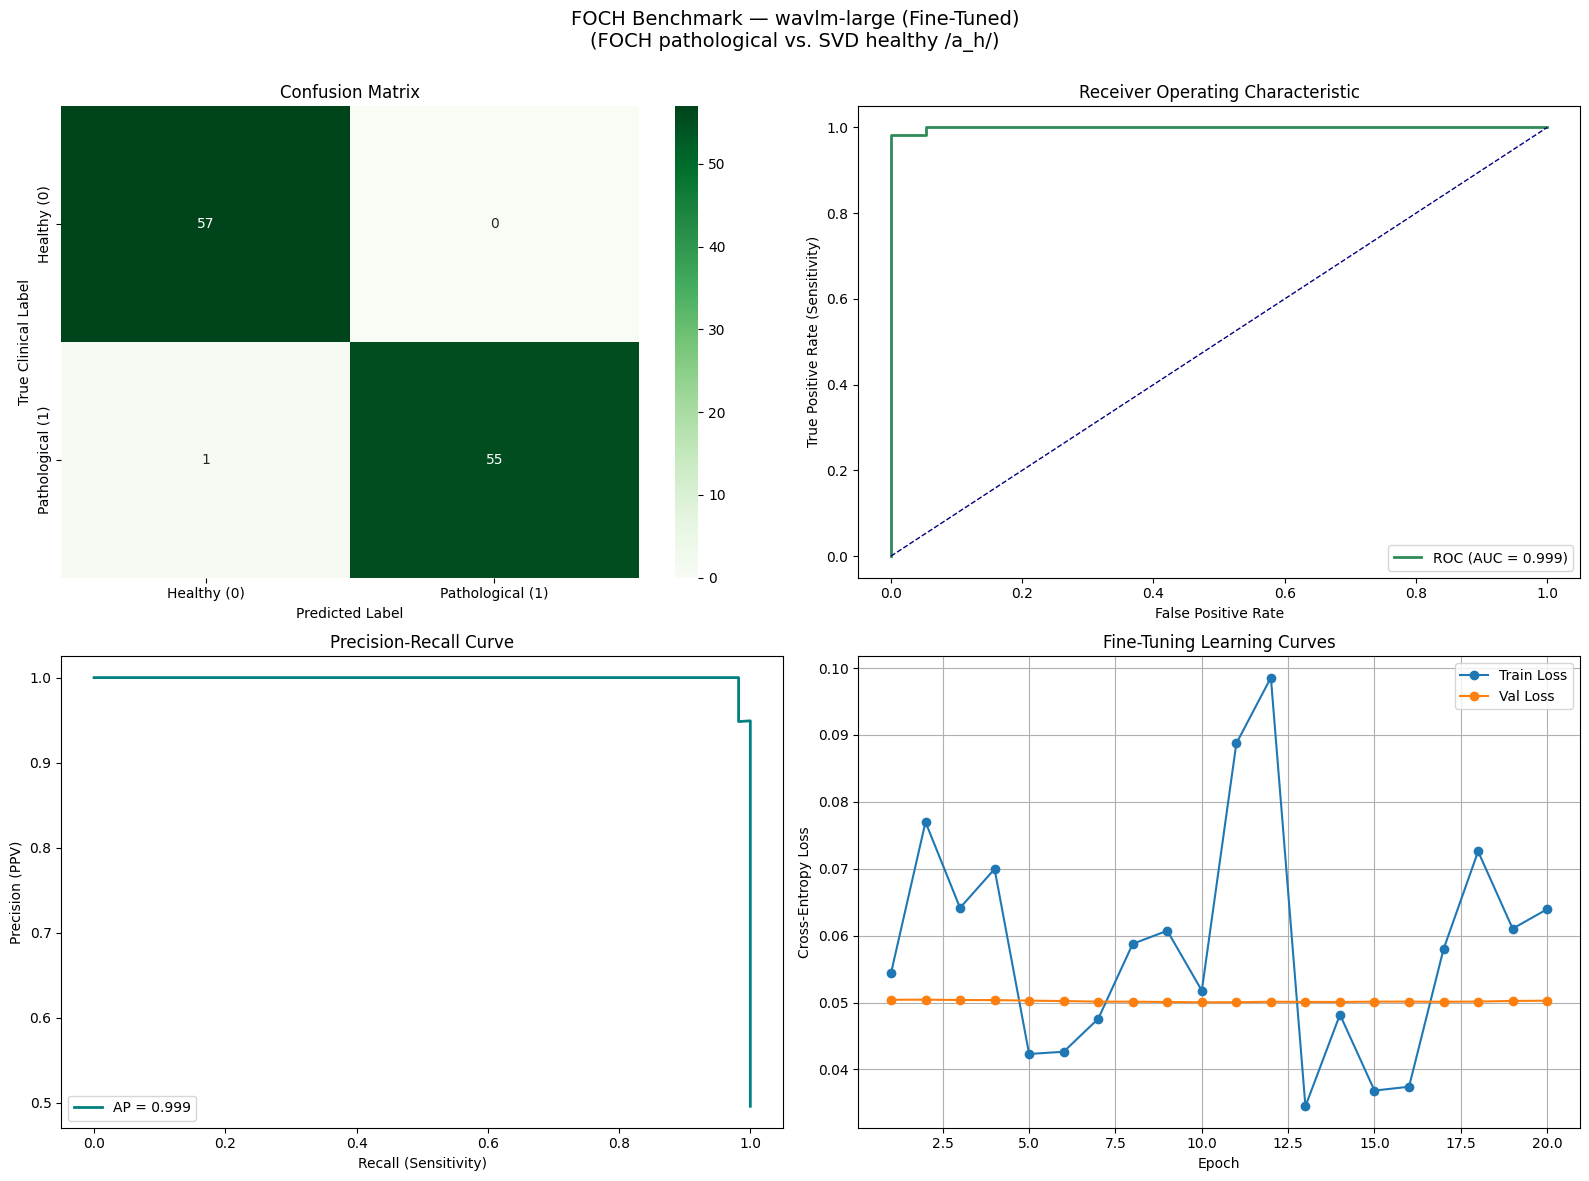


Key metrics — wavlm-large fine-tuned
  ROC AUC        : 0.9991  (Δ -0.0000 vs. benchmark)
  Avg. Precision : 0.9991  (Δ -0.0000 vs. benchmark)
  Val Accuracy   : 0.9912  (Δ +0.0312 vs. benchmark)

  Dashboard saved to C:/Users/AdminIA/Documents/models/foch-benchmark\wavlm-large\finetuned\eval_dashboard_finetuned.png


In [13]:
# CELL 10 — Fine-Tuned Model Evaluation
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score,
)

ft_model.eval()
ft_labels, ft_preds, ft_probs = [], [], []

print('Running inference on validation set (fine-tuned model)...')
with torch.no_grad():
    for xb, yb in val_loader:
        xb     = xb.to(device)
        logits = ft_model(xb).logits
        probs  = F.softmax(logits, dim=1)
        preds  = logits.argmax(dim=1)
        ft_probs.extend(probs.cpu().numpy())
        ft_preds.extend(preds.cpu().numpy())
        ft_labels.extend(yb.numpy())

ft_labels = np.array(ft_labels)
ft_preds  = np.array(ft_preds)
ft_probs  = np.array(ft_probs)
target_names = ['Healthy (0)', 'Pathological (1)']

print('\n' + '─' * 60)
print(f'Fine-tuned model : {BEST_MODEL}')
print('─' * 60)
print(classification_report(ft_labels, ft_preds, target_names=target_names))

# ── 2×2 Dashboard ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    f'FOCH Benchmark — {BEST_MODEL} (Fine-Tuned)\n'
    f'(FOCH pathological vs. SVD healthy /a_h/)',
    fontsize=14,
)

# Confusion Matrix
cm = confusion_matrix(ft_labels, ft_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0, 0],
            xticklabels=target_names, yticklabels=target_names)
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_ylabel('True Clinical Label')
axes[0, 0].set_xlabel('Predicted Label')

# ROC Curve
pos_probs = ft_probs[:, 1]
fpr, tpr, _ = roc_curve(ft_labels, pos_probs)
ft_roc_auc  = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, lw=2, color='seagreen', label=f'ROC (AUC = {ft_roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], '--', color='navy', lw=1)
axes[0, 1].set_title('Receiver Operating Characteristic')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate (Sensitivity)')
axes[0, 1].legend(loc='lower right')

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(ft_labels, pos_probs)
ft_ap = average_precision_score(ft_labels, pos_probs)
axes[1, 0].plot(rec, prec, lw=2, color='teal', label=f'AP = {ft_ap:.3f}')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].set_xlabel('Recall (Sensitivity)')
axes[1, 0].set_ylabel('Precision (PPV)')
axes[1, 0].legend()

# Fine-tuning Learning Curves
axes[1, 1].plot(range(1, len(ft_train_hist) + 1), ft_train_hist, 'o-', label='Train Loss')
axes[1, 1].plot(range(1, len(ft_val_hist)   + 1), ft_val_hist,   'o-', label='Val Loss')
axes[1, 1].set_title('Fine-Tuning Learning Curves')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Cross-Entropy Loss')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
ft_dashboard_path = os.path.join(FT_CKPT_DIR, 'eval_dashboard_finetuned.png')
plt.savefig(ft_dashboard_path, dpi=150, bbox_inches='tight')
plt.show()

# ── Delta vs. benchmark run ───────────────────────────────────────────────────
bench_auc, bench_ap, bench_acc = BENCHMARK_RESULTS.get(BEST_MODEL, (None, None, None))
ft_acc = (ft_preds == ft_labels).mean()

print(f'\nKey metrics — {BEST_MODEL} fine-tuned')
print(f'  ROC AUC        : {ft_roc_auc:.4f}', end='')
if bench_auc: print(f'  (Δ {ft_roc_auc - bench_auc:+.4f} vs. benchmark)')
else: print()
print(f'  Avg. Precision : {ft_ap:.4f}', end='')
if bench_ap:  print(f'  (Δ {ft_ap - bench_ap:+.4f} vs. benchmark)')
else: print()
print(f'  Val Accuracy   : {ft_acc:.4f}', end='')
if bench_acc: print(f'  (Δ {ft_acc - bench_acc:+.4f} vs. benchmark)')
else: print()
print(f'\n  Dashboard saved to {ft_dashboard_path}')